In [9]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn import functional as F

import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


def detect_best_device():
    """自动选择最优设备并返回运行参数。"""
    if torch.cuda.is_available():
        return {
            'device': torch.device('cuda'),
            'backend': 'cuda',
            'pin_memory': True,
            'num_workers': min(8, max(2, (os.cpu_count() or 4) // 2)),
            'persistent_workers': True,
        }

    # Apple Silicon fallback (for cross-platform notebook portability)
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return {
            'device': torch.device('mps'),
            'backend': 'mps',
            'pin_memory': False,
            'num_workers': min(4, max(1, (os.cpu_count() or 4) // 2)),
            'persistent_workers': True,
        }

    # x86 CPU or other CPU-only environments
    return {
        'device': torch.device('cpu'),
        'backend': 'cpu',
        'pin_memory': False,
        'num_workers': min(8, max(2, (os.cpu_count() or 4) // 2)),
        'persistent_workers': True,
    }


runtime_cfg = detect_best_device()
device = runtime_cfg['device']
DATALOADER_NUM_WORKERS = runtime_cfg['num_workers']
DATALOADER_PIN_MEMORY = runtime_cfg['pin_memory']
DATALOADER_PERSISTENT_WORKERS = runtime_cfg['persistent_workers']

print(f"使用设备: {device}")
print(f"后端: {runtime_cfg['backend']}")
print(f"DataLoader workers: {DATALOADER_NUM_WORKERS}")
print(f"DataLoader pin_memory: {DATALOADER_PIN_MEMORY}")

# 基本配置
BASE_DIR = Path('/home/thelia/Learn/ML/MyCode/LearningMachineLearning/Thelia/ProjectSekai')
TRAINING_DATA_DIR = BASE_DIR / 'TrainingData'
AUGMENTED_DATA_DIR = BASE_DIR / 'AugmentedTrainingData'
TRAIN_DATA_DIR = AUGMENTED_DATA_DIR / 'train'
TEST_DATA_DIR = AUGMENTED_DATA_DIR / 'test'
CODE_DIR = BASE_DIR / 'Codes'

# 超参数
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
NUM_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 5
RANDOM_SEED = 42
TEST_SPLIT_RATIO = 0.2

# 类别定义
CLASS_NAMES = ['Enanan', 'Kanade', 'Mafuyu', 'Mizuki']
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}

print(f"配置信息:")
print(f"  原始训练数据目录: {TRAINING_DATA_DIR}")
print(f"  增强后数据目录: {AUGMENTED_DATA_DIR}")
print(f"  训练集目录: {TRAIN_DATA_DIR}")
print(f"  测试集目录: {TEST_DATA_DIR}")
print(f"  类别数: {NUM_CLASSES}")
print(f"  类别: {CLASS_NAMES}")
print(f"  批大小: {BATCH_SIZE}")
print(f"  学习率: {LEARNING_RATE}")
print(f"  最大epoch数: {NUM_EPOCHS}")
print(f"  测试集比例: {TEST_SPLIT_RATIO}")

使用设备: cpu
后端: cpu
DataLoader workers: 8
DataLoader pin_memory: False
配置信息:
  原始训练数据目录: /home/thelia/Learn/ML/MyCode/LearningMachineLearning/Thelia/ProjectSekai/TrainingData
  增强后数据目录: /home/thelia/Learn/ML/MyCode/LearningMachineLearning/Thelia/ProjectSekai/AugmentedTrainingData
  训练集目录: /home/thelia/Learn/ML/MyCode/LearningMachineLearning/Thelia/ProjectSekai/AugmentedTrainingData/train
  测试集目录: /home/thelia/Learn/ML/MyCode/LearningMachineLearning/Thelia/ProjectSekai/AugmentedTrainingData/test
  类别数: 4
  类别: ['Enanan', 'Kanade', 'Mafuyu', 'Mizuki']
  批大小: 32
  学习率: 0.001
  最大epoch数: 15
  测试集比例: 0.2


## 基础配置

这一节初始化 PyTorch、路径和超参数，并定义四个角色的类别映射。后续所有数据加载、模型构建和训练逻辑都会复用这里的配置。

In [8]:
# ==================== Phase 0: 数据增强 + 8:2 切分 ====================
# 规则：先按原始图片分 train/test，再对每张原图生成 6 个变体，避免数据泄露

import random
import shutil

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

def make_six_variants(img):
    """对一张图片生成 6 个变体。"""
    return [
        ("original", img),
        ("h_flip", img.transpose(Image.FLIP_LEFT_RIGHT)),
        ("v_flip", img.transpose(Image.FLIP_TOP_BOTTOM)),
        ("hv_flip", img.transpose(Image.FLIP_LEFT_RIGHT).transpose(Image.FLIP_TOP_BOTTOM)),
        ("rot90", img.rotate(90, expand=True)),
        ("rot270", img.rotate(270, expand=True)),
    ]


def prepare_output_dirs(base_dir, class_names):
    """创建 train/test 输出目录。"""
    if base_dir.exists():
        shutil.rmtree(base_dir)
    for split_name in ['train', 'test']:
        for class_name in class_names:
            (base_dir / split_name / class_name).mkdir(parents=True, exist_ok=True)


def split_files(file_list, test_ratio=0.2, seed=42):
    """按文件级别切分 train/test，返回 (train_files, test_files)。"""
    file_list = list(file_list)
    rng = random.Random(seed)
    rng.shuffle(file_list)
    test_size = max(1, int(round(len(file_list) * test_ratio))) if len(file_list) > 1 else len(file_list)
    test_files = file_list[:test_size]
    train_files = file_list[test_size:]
    return train_files, test_files


def get_source_files(class_source_dir):
    """获取原始 JPEG 文件，兼容 .jpg 和 .jpeg。"""
    jpg_files = sorted(class_source_dir.glob('*.jpg'))
    jpeg_files = sorted(class_source_dir.glob('*.jpeg'))
    return sorted(jpg_files + jpeg_files)


def augment_and_save_split(source_files, output_dir, class_name, split_name):
    """对给定 split 的原图生成 6 个 JPEG 变体。"""
    target_dir = output_dir / split_name / class_name
    target_dir.mkdir(parents=True, exist_ok=True)
    generated = 0
    for source_file in tqdm(source_files, desc=f"{class_name}-{split_name}"):
        try:
            img = Image.open(source_file).convert('RGB')
            base_name = source_file.stem
            for variant_name, variant_img in make_six_variants(img):
                variant_img.save(
                    target_dir / f'{base_name}_{variant_name}.jpg',
                    'JPEG',
                    quality=95,
                    optimize=True,
                )
                generated += 1
        except Exception as exc:
            print(f"  错误处理 {source_file.name}: {exc}")
    return generated


print("=" * 60)
print("开始数据增强：单独输出目录 + 原图级别8:2切分 + 每图6个变体")
print("=" * 60)

prepare_output_dirs(AUGMENTED_DATA_DIR, CLASS_NAMES)

total_train_generated = 0
total_test_generated = 0
source_summary = {}

for class_name in CLASS_NAMES:
    class_source_dir = TRAINING_DATA_DIR / class_name
    source_files = get_source_files(class_source_dir)
    source_summary[class_name] = len(source_files)

    if not source_files:
        print(f"⚠ {class_name} 目录中没有找到 .jpg 或 .jpeg 文件: {class_source_dir}")
        continue

    train_files, test_files = split_files(source_files, test_ratio=TEST_SPLIT_RATIO, seed=RANDOM_SEED)
    print(f"\n{class_name}: 原始图片 {len(source_files)} 张, train {len(train_files)} 张, test {len(test_files)} 张")

    train_count = augment_and_save_split(train_files, AUGMENTED_DATA_DIR, class_name, 'train')
    test_count = augment_and_save_split(test_files, AUGMENTED_DATA_DIR, class_name, 'test')

    total_train_generated += train_count
    total_test_generated += test_count

    print(f"✓ {class_name}: 训练集生成 {train_count} 张，测试集生成 {test_count} 张")

print("\n" + "=" * 60)
print("数据增强完成！")
print(f"训练集总计: {total_train_generated} 张JPEG图片")
print(f"测试集总计: {total_test_generated} 张JPEG图片")
print("=" * 60)

print("\n数据集统计:")
for split_name in ['train', 'test']:
    for class_name in CLASS_NAMES:
        class_dir = AUGMENTED_DATA_DIR / split_name / class_name
        jpg_count = len(list(class_dir.glob('*.jpg'))) if class_dir.exists() else 0
        print(f"  {split_name}/{class_name}: {jpg_count} 张JPEG图片")


开始数据增强：单独输出目录 + 原图级别8:2切分 + 每图6个变体

Enanan: 原始图片 87 张, train 70 张, test 17 张


Enanan-test: 100%|██████████| 17/17 [00:00<00:00, 21.39it/s]


✓ Enanan: 训练集生成 420 张，测试集生成 102 张

Kanade: 原始图片 87 张, train 70 张, test 17 张


Kanade-test: 100%|██████████| 17/17 [00:00<00:00, 20.01it/s]


✓ Kanade: 训练集生成 420 张，测试集生成 102 张

Mafuyu: 原始图片 86 张, train 69 张, test 17 张


Mafuyu-test: 100%|██████████| 17/17 [00:00<00:00, 18.36it/s]


✓ Mafuyu: 训练集生成 414 张，测试集生成 102 张

Mizuki: 原始图片 85 张, train 68 张, test 17 张


Mizuki-test: 100%|██████████| 17/17 [00:00<00:00, 19.79it/s]

✓ Mizuki: 训练集生成 408 张，测试集生成 102 张

数据增强完成！
训练集总计: 1662 张JPEG图片
测试集总计: 408 张JPEG图片

数据集统计:
  train/Enanan: 420 张JPEG图片
  train/Kanade: 420 张JPEG图片
  train/Mafuyu: 414 张JPEG图片
  train/Mizuki: 408 张JPEG图片
  test/Enanan: 102 张JPEG图片
  test/Kanade: 102 张JPEG图片
  test/Mafuyu: 102 张JPEG图片
  test/Mizuki: 102 张JPEG图片


## 数据增强与切分

这一节会读取原始 JPEG 图片，先按原图级别切成训练集和测试集，再对每张图生成 6 个增强版本，输出到单独的数据目录中，避免训练和测试数据泄露。

In [ ]:
# 调试：检查数据目录结构
print("调试：检查目录结构")
print(f"TRAINING_DATA_DIR: {TRAINING_DATA_DIR}")
print(f"存在: {TRAINING_DATA_DIR.exists()}")

if TRAINING_DATA_DIR.exists():
    print(f"\nTRAINING_DATA_DIR 内容:")
    for item in TRAINING_DATA_DIR.iterdir():
        print(f"  {item.name} ({'目录' if item.is_dir() else '文件'})")
        if item.is_dir():
            contents = list(item.glob('*'))
            print(f"    包含 {len(contents)} 项")
            if len(contents) > 0:
                print(f"    样例: {contents[0].name}")
else:
    print("TRAINING_DATA_DIR 不存在！")


## 数据目录检查

这一节用于确认原始训练数据目录是否存在，以及每个角色文件夹里是否真的放入了图片文件。

In [ ]:
# ==================== Phase 1-4: 数据加载、预训练模型、训练与评估 ====================
from collections import Counter
import random

PROJECT_SEKAI_MODEL_DIR = BASE_DIR / 'checkpoints'
PROJECT_SEKAI_MODEL_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH = PROJECT_SEKAI_MODEL_DIR / 'resnet50_projectsekai_jpeg_best.pth'
IMG_SIZE = 224
VAL_RATIO = 0.1
RUN_TRAINING = True

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])


def build_samples(root_dir):
    """收集目录下所有图片样本，返回 (path, label_index) 列表。"""
    samples = []
    for class_name in CLASS_NAMES:
        class_dir = root_dir / class_name
        if not class_dir.exists():
            continue
        for extension in ('*.jpg', '*.jpeg'):
            for image_path in sorted(class_dir.glob(extension)):
                samples.append((image_path, CLASS_TO_IDX[class_name]))
    return samples


class ProjectSekaiDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = list(samples)
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label = self.samples[index]
        image = Image.open(image_path).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        return image, label


train_samples_all = build_samples(TRAIN_DATA_DIR)
test_samples = build_samples(TEST_DATA_DIR)

rng = random.Random(RANDOM_SEED)
rng.shuffle(train_samples_all)

if len(train_samples_all) == 0:
    print('⚠ 训练集为空，请先确认 AugmentedTrainingData/train 下存在 JPEG 图片。')

val_size = max(1, int(round(len(train_samples_all) * VAL_RATIO))) if len(train_samples_all) > 1 else 0
val_samples = train_samples_all[:val_size]
train_samples = train_samples_all[val_size:]

train_dataset = ProjectSekaiDataset(train_samples, transform=train_transform)
val_dataset = ProjectSekaiDataset(val_samples, transform=eval_transform)
test_dataset = ProjectSekaiDataset(test_samples, transform=eval_transform)

dataloader_kwargs = {
    'num_workers': DATALOADER_NUM_WORKERS,
    'pin_memory': DATALOADER_PIN_MEMORY,
    'persistent_workers': DATALOADER_PERSISTENT_WORKERS and DATALOADER_NUM_WORKERS > 0,
}

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, **dataloader_kwargs)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, **dataloader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **dataloader_kwargs)

print('=' * 60)
print('数据加载完成')
print(f'训练样本数: {len(train_dataset)}')
print(f'验证样本数: {len(val_dataset)}')
print(f'测试样本数: {len(test_dataset)}')
print('训练集类别分布:', Counter(label for _, label in train_samples))
print('验证集类别分布:', Counter(label for _, label in val_samples))
print('测试集类别分布:', Counter(label for _, label in test_samples))
print('=' * 60)


def build_pretrained_resnet50(num_classes):
    """加载 ImageNet 预训练的 ResNet50，并替换分类头。"""
    weights = models.ResNet50_Weights.DEFAULT
    model = models.resnet50(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(in_features, num_classes)
    )

    for param in model.layer3.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True

    return model


model = build_pretrained_resnet50(NUM_CLASSES).to(device)

optimizer = optim.Adam(
    [
        {'params': model.layer3.parameters(), 'lr': 1e-4},
        {'params': model.layer4.parameters(), 'lr': 1e-4},
        {'params': model.fc.parameters(), 'lr': 1e-3},
    ],
    weight_decay=1e-4,
)
criterion = nn.CrossEntropyLoss()
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print('\n预训练模型已创建：ResNet50 (ImageNet weights)')
print(model.fc)
print('可训练参数量:', sum(p.numel() for p in model.parameters() if p.requires_grad))


def run_epoch(model, loader, criterion, optimizer=None):
    """执行一个 epoch，返回 avg_loss, accuracy, targets, predictions。"""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_targets = []
    all_predictions = []

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(images)
            loss = criterion(outputs, targets)
            if is_train:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        all_targets.extend(targets.detach().cpu().tolist())
        all_predictions.extend(predictions.detach().cpu().tolist())

    dataset_size = len(loader.dataset)
    avg_loss = running_loss / max(dataset_size, 1)
    accuracy = accuracy_score(all_targets, all_predictions) if dataset_size > 0 else 0.0
    return avg_loss, accuracy, all_targets, all_predictions


history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'test_loss': [],
    'test_acc': [],
}

best_val_loss = float('inf')
patience_counter = 0

if RUN_TRAINING:
    print('\n开始训练...')
    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_loss, val_acc, _, _ = run_epoch(model, val_loader, criterion, optimizer=None)
        test_loss, test_acc, _, _ = run_epoch(model, test_loader, criterion, optimizer=None)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        scheduler.step(val_loss)

        print(
            f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
            f'train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | '
            f'val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | '
            f'test_loss={test_loss:.4f} | test_acc={test_acc:.4f}'
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(
                {
                    'model_state_dict': model.state_dict(),
                    'class_names': CLASS_NAMES,
                    'class_to_idx': CLASS_TO_IDX,
                    'img_size': IMG_SIZE,
                    'best_val_loss': best_val_loss,
                },
                BEST_MODEL_PATH,
            )
            print(f'  保存最佳模型到: {BEST_MODEL_PATH}')
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print('  触发早停，结束训练。')
                break

    print('\n训练结束。')
else:
    print('\n训练流程已准备好。将 RUN_TRAINING = True 后开始正式训练。')
    print(f'模型保存路径: {BEST_MODEL_PATH}')


数据加载完成
训练样本数: 1496
验证样本数: 166
测试样本数: 408
训练集类别分布: Counter({1: 379, 0: 377, 2: 374, 3: 366})
验证集类别分布: Counter({0: 43, 3: 42, 1: 41, 2: 40})
测试集类别分布: Counter({0: 102, 1: 102, 2: 102, 3: 102})

预训练模型已创建：ResNet50 (ImageNet weights)
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=2048, out_features=4, bias=True)
)
可训练参数量: 22071300

开始训练...
Epoch 01/15 | train_loss=0.9262 | train_acc=0.6384 | val_loss=0.2693 | val_acc=0.9096 | test_loss=0.9609 | test_acc=0.6985
  保存最佳模型到: /home/thelia/Learn/ML/MyCode/LearningMachineLearning/Thelia/ProjectSekai/checkpoints/resnet50_projectsekai_jpeg_best.pth


KeyboardInterrupt: 

## 数据加载与预训练模型

这一节把增强后的 JPEG 数据读入 DataLoader，并引入 ImageNet 预训练的 ResNet50 作为特征提取器，替换最后的分类头后继续微调后层。

已加载最佳模型: /home/thelia/Learn/ML/MyCode/LearningMachineLearning/Thelia/ProjectSekai/checkpoints/resnet50_projectsekai_jpeg_best.pth
测试集 Loss: 0.9609
测试集 Accuracy: 0.6985

分类报告:
              precision    recall  f1-score   support

      Enanan     0.8966    0.5098    0.6500       102
      Kanade     0.8219    0.5882    0.6857       102
      Mafuyu     0.5515    0.8922    0.6816       102
      Mizuki     0.7321    0.8039    0.7664       102

    accuracy                         0.6985       408
   macro avg     0.7505    0.6985    0.6959       408
weighted avg     0.7505    0.6985    0.6959       408



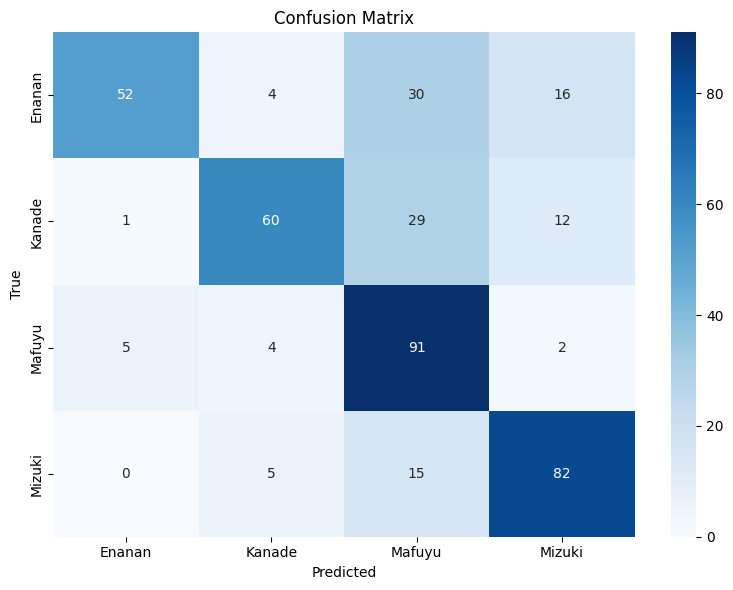

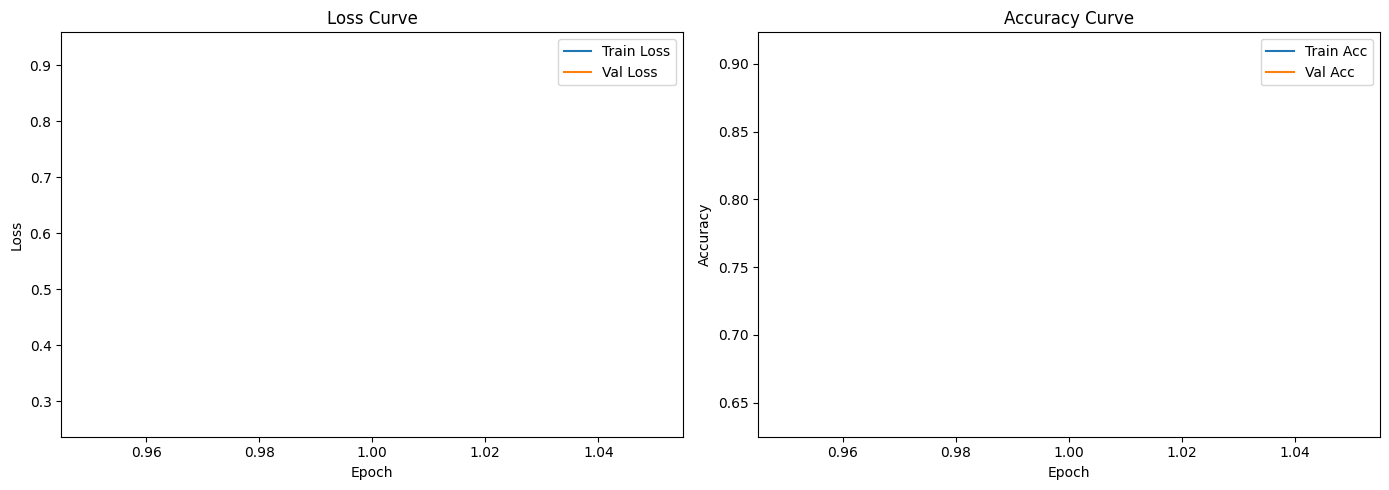

In [8]:
# ==================== Phase 5: 测试评估与可视化 ====================

def plot_history(history_dict):
    """绘制训练过程曲线。"""
    if not history_dict['train_loss']:
        print('当前没有训练历史，先运行训练再绘图。')
        return

    epochs = range(1, len(history_dict['train_loss']) + 1)
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_dict['train_loss'], label='Train Loss')
    plt.plot(epochs, history_dict['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_dict['train_acc'], label='Train Acc')
    plt.plot(epochs, history_dict['val_acc'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curve')
    plt.legend()

    plt.tight_layout()
    plt.show()


def evaluate_on_test(model, loader):
    """在测试集上评估模型，并输出分类报告与混淆矩阵。"""
    test_loss, test_acc, y_true, y_pred = run_epoch(model, loader, criterion, optimizer=None)
    print(f'测试集 Loss: {test_loss:.4f}')
    print(f'测试集 Accuracy: {test_acc:.4f}')
    print('\n分类报告:')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

    return test_loss, test_acc


if BEST_MODEL_PATH.exists():
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f'已加载最佳模型: {BEST_MODEL_PATH}')
    _ = evaluate_on_test(model, test_loader)
else:
    print(f'尚未找到最佳模型文件: {BEST_MODEL_PATH}')
    print('请先将 RUN_TRAINING 设为 True 并运行训练 cell。')

plot_history(history)


## 测试评估与可视化

这一节会在训练结束后加载最佳模型，计算测试集损失、准确率、分类报告和混淆矩阵，并绘制训练曲线。